#STEP 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#STEP 2: Load Dataset

In [9]:
df = pd.read_csv(r"Dataset for Sales Prediction.csv")

print("="*50)
print("DATASET SHAPE")
print("="*50)
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

DATASET SHAPE
(200, 4)

FIRST 5 ROWS
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


#STEP 3: Dataset Information


In [10]:
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)

df.info()

print("\nMISSING VALUES")
print(df.isnull().sum())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

MISSING VALUES
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


#STEP 4: Statistical Summary

In [11]:
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)

print(df.describe())


STATISTICAL SUMMARY
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


#STEP 5: Target Variable Distribution



TARGET VARIABLE DISTRIBUTION
count    200.000000
mean      15.130500
std        5.283892
min        1.600000
25%       11.000000
50%       16.000000
75%       19.050000
max       27.000000
Name: Sales, dtype: float64


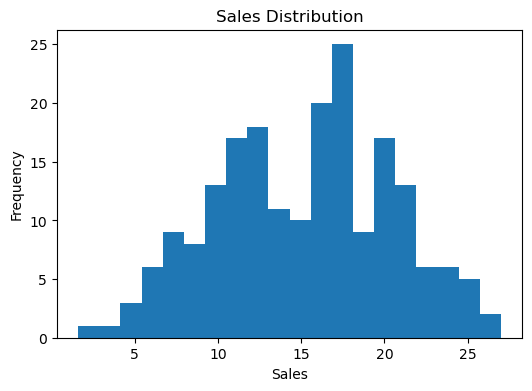

In [12]:
print("\n" + "="*50)
print("TARGET VARIABLE DISTRIBUTION")
print("="*50)

print(df['Sales'].describe())

plt.figure(figsize=(6,4))
plt.hist(df['Sales'], bins=20)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

#STEP 6: Exploratory Data Analysis (EDA)


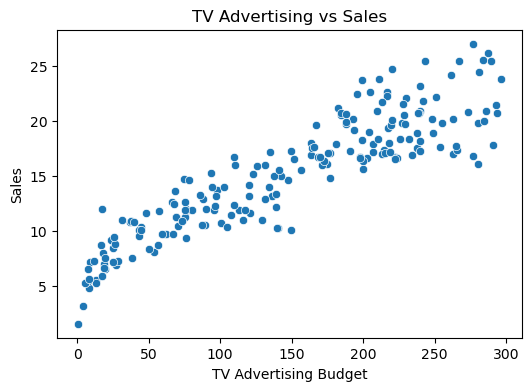

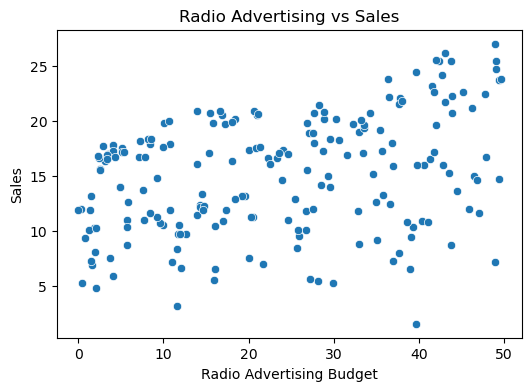

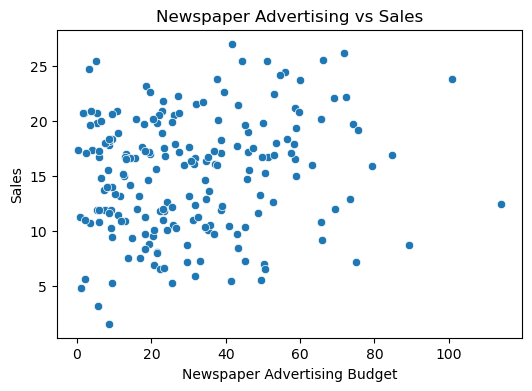

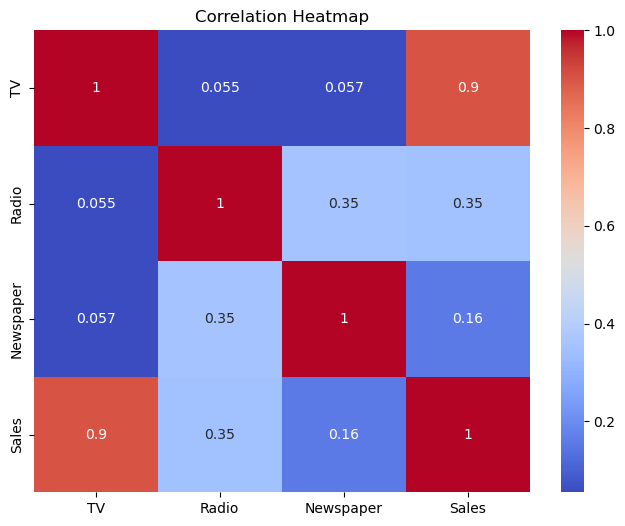

In [13]:
# TV vs Sales
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales', data=df)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.show()

# Radio vs Sales
plt.figure(figsize=(6,4))
sns.scatterplot(x='Radio', y='Sales', data=df)

plt.title("Radio Advertising vs Sales")
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")

plt.show()
# Newspaper vs Sales
plt.figure(figsize=(6,4))
sns.scatterplot(x='Newspaper', y='Sales', data=df)

plt.title("Newspaper Advertising vs Sales")
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")

plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()


#STEP 7: Data Cleaning

In [14]:
print("\n" + "="*50)
print("MISSING VALUES AFTER CHECKING")
print("="*50)

print(df.isnull().sum())



MISSING VALUES AFTER CHECKING
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


#STEP 8: Save Clean Dataset

In [15]:
df.to_csv("Advertising_Cleaned.csv", index=False)

print("\nAdvertising_Cleaned.csv Saved Successfully")



Advertising_Cleaned.csv Saved Successfully


#STEP 9: Feature Selection

In [16]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)



Features Shape: (200, 3)
Target Shape: (200,)


#STEP 10: Train-Test Split

In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (160, 3)
Testing Data Shape: (40, 3)


#STEP 11: Train Model

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

print("\nMODEL TRAINING COMPLETED")


MODEL TRAINING COMPLETED


#STEP 12: Predictions



In [19]:
y_pred = model.predict(X_test)

#STEP 13: Model Evaluation

In [20]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

# Prediction Sample
print("\nPREDICTION SAMPLE")

sample = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print(sample.head(10))




MODEL EVALUATION
R2 Score : 0.9059
MAE      : 1.2748
MSE      : 2.9078
RMSE     : 1.7052

PREDICTION SAMPLE
   Actual Sales  Predicted Sales
0          16.9        17.034772
1          22.4        20.409740
2          21.4        23.723989
3           7.3         9.272785
4          24.7        21.682719
5          12.6        12.569402
6          22.3        21.081195
7           8.4         8.690350
8          16.5        17.237013
9          16.1        16.666575


#STEP 14: Actual vs Predicted Sales

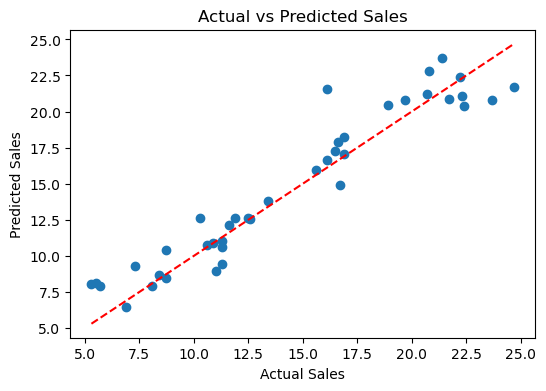

In [21]:
plt.figure(figsize=(6,4))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

#STEP 15: Feature Importance


FEATURE IMPORTANCE
     Feature  Coefficient
0         TV     0.054509
1      Radio     0.100945
2  Newspaper     0.004337


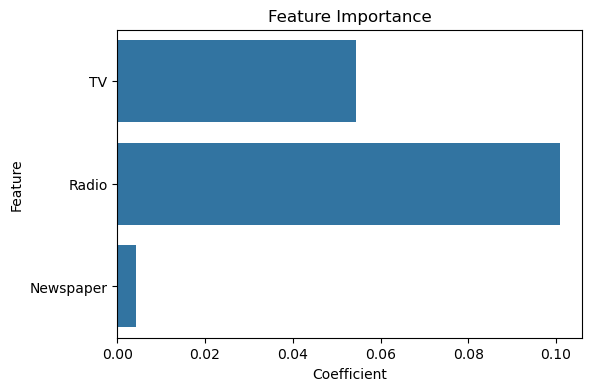

In [22]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFEATURE IMPORTANCE")
print(importance)

plt.figure(figsize=(6,4))
sns.barplot(
    data=importance,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

#STEP 16: Project Insights

In [23]:
print("\n" + "="*50)
print("PROJECT INSIGHTS")
print("="*50)

print("1. The dataset contains 200 advertising records and 4 columns.")
print("2. TV advertising has the strongest impact on sales.")
print("3. Radio advertising also contributes significantly to sales growth.")
print("4. Newspaper advertising has a relatively smaller influence on sales.")
print("5. Strong positive correlations exist between advertising spending and sales.")
print("6. Linear Regression achieved a strong R2 Score.")
print("7. The model successfully predicts future sales based on advertising budgets.")
print("8. Businesses can use this model to optimize marketing expenditure.")
print("9. Data-driven advertising decisions can improve sales performance.")
print("10. Machine Learning can help forecast business outcomes effectively.")


PROJECT INSIGHTS
1. The dataset contains 200 advertising records and 4 columns.
2. TV advertising has the strongest impact on sales.
3. Radio advertising also contributes significantly to sales growth.
4. Newspaper advertising has a relatively smaller influence on sales.
5. Strong positive correlations exist between advertising spending and sales.
6. Linear Regression achieved a strong R2 Score.
7. The model successfully predicts future sales based on advertising budgets.
8. Businesses can use this model to optimize marketing expenditure.
9. Data-driven advertising decisions can improve sales performance.
10. Machine Learning can help forecast business outcomes effectively.
